In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from itertools import cycle

In [2]:
# u_t = u_xx, x in [0, 1], t in [0, 1]
# u(x, 0) = sin(pi * x)
# u(0, t) = u(1, t) = 0
def exact_sol(x, t):
    return np.exp(-np.pi * np.pi * t) * np.sin(np.pi * x)

In [3]:
N_x = 1000
N_t = 1000

# computando a solução exata numa malha
xs = np.linspace(0, 1, N_x)
ts = np.linspace(0, 1, N_t)

us = exact_sol(*np.meshgrid(xs, ts))

In [4]:
N = 3000 # quantos pontos vamos ter a solução exata para treino
N_contorno = N // 10 # 10% pontos de contorno
N_inicial = N // 10 # 10% condição inicial
N_colocacao = N - N_contorno - N_inicial

idxs_t_contorno = np.random.randint(low=0, high=ts.shape[0], size=N_contorno)
idxs_t_inicial = np.zeros(N_inicial, dtype=np.int32) # t == 0 <=> idx == 0 nesse caso
idxs_t_colocacao = np.random.randint(low=0, high=ts.shape[0], size=N_colocacao)

# x == 0 <=> idx == 0 && x == 1 <=> idx == N_x - 1
idxs_x_contorno = np.concatenate((np.zeros(N_contorno // 2, dtype=np.int32), np.full(N_contorno - N_contorno // 2, N_x - 1, dtype=np.int32)))
idxs_x_inicial = np.random.randint(low=0, high=xs.shape[0], size=N_inicial)
idxs_x_colocacao = np.random.randint(low=0, high=xs.shape[0], size=N_colocacao)

# X[:, 0] -> t (primeira coluna)
# X[:, 1:] -> x (resto)
X_contorno = torch.tensor(np.stack((ts[idxs_t_contorno], xs[idxs_x_contorno]), axis=1), dtype=torch.float32)
X_inicial = torch.tensor(np.stack((ts[idxs_t_inicial], xs[idxs_x_inicial]), axis=1), dtype=torch.float32)
X_colocacao = torch.tensor(np.stack((ts[idxs_t_colocacao], xs[idxs_x_colocacao]), axis=1), dtype=torch.float32)

y_contorno = torch.tensor(us[idxs_t_contorno, idxs_x_contorno], dtype=torch.float32)
y_inicial = torch.tensor(us[idxs_t_inicial, idxs_x_inicial], dtype=torch.float32)
y_colocacao = torch.tensor(us[idxs_t_colocacao, idxs_x_colocacao], dtype=torch.float32)

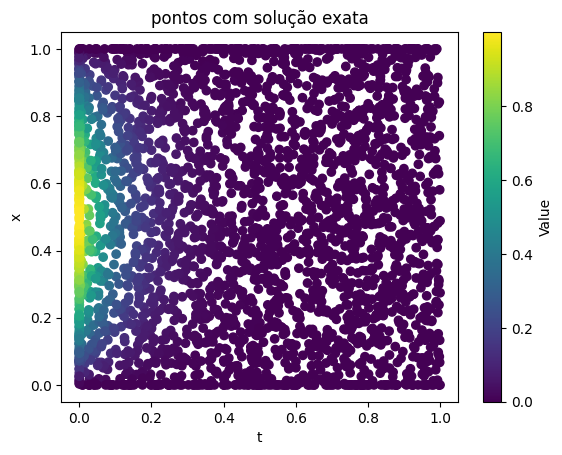

In [5]:
plt.scatter(X_colocacao[:, 0], X_colocacao[:, 1:], c=y_colocacao, cmap="viridis", vmin=us.min(), vmax=us.max())
plt.scatter(X_contorno[:, 0], X_contorno[:, 1:], c=y_contorno, cmap="viridis", vmin=us.min(), vmax=us.max())
plt.scatter(X_inicial[:, 0], X_inicial[:, 1:], c=y_inicial, cmap="viridis", vmin=us.min(), vmax=us.max())
plt.xlabel('t')
plt.ylabel('x')
plt.title('pontos com solução exata')
plt.colorbar(label='Value')
plt.show()

In [6]:
lambda_1 = 1.0

In [7]:
def pinn_loss(X_batch, y_fake, y_real_contorno, y_fake_contorno, y_real_inicial, y_fake_inicial):
    
    dy_dX = torch.autograd.grad(y_fake, X_batch, grad_outputs=torch.ones_like(y_fake), create_graph=True)[0]
    
    dy_dt = dy_dX[:, :1]
    dy_dx = dy_dX[:, 1:]

    dy_dxx = torch.autograd.grad(dy_dx, X_batch, grad_outputs=torch.ones_like(y_fake), create_graph=True)[0][:, 1:]

    L_f = torch.mean((dy_dt - dy_dxx) ** 2)
    L_b1 = torch.mean((y_fake_inicial - y_real_inicial) ** 2)
    L_b2 = torch.mean((y_fake_contorno - y_real_contorno) ** 2)

    L_PINN = L_f + lambda_1 * (L_b1 + L_b2)

    return L_PINN

In [8]:
class PINN(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim),
        )
    def forward(self, z):
        return self.net(z)



PINN_model = PINN(2, 1, 32)

In [9]:
n_iter = 5000

batch_size = 256
batch_contorno = batch_size // 10
batch_inicial = batch_size // 10
batch_colocacao = batch_size - batch_contorno - batch_inicial

lr = 1e-3
optimizer = optim.Adam(PINN_model.parameters(), lr=lr)

In [10]:
for it in range(n_iter):

    # replace=False pra não pegar o mesmo ponto duas vezes
    idxs_batch_contorno = np.random.choice(N_contorno, size=batch_contorno, replace=False)
    idxs_batch_inicial = np.random.choice(N_inicial, size=batch_inicial, replace=False)
    idxs_batch_colocacao = np.random.choice(N_colocacao, size=batch_colocacao, replace=False)

    # separar em contorno, inicial e colocação só ajuda na hora de calcular o L_PINN
    X_batch_contorno = X_contorno[idxs_batch_contorno]
    X_batch_inicial = X_inicial[idxs_batch_inicial]
    X_batch_colocacao = X_colocacao[idxs_batch_colocacao]
    
    # pro resto dos calculos, junta tudo numa coisa só que tudo fica melhor
    X_batch = torch.cat((X_batch_contorno, X_batch_inicial, X_batch_colocacao), dim=0).requires_grad_(True)

    # com o y real, só precisa das condições de contorno e fronteira
    y_batch_contorno = y_contorno[idxs_batch_contorno].view(-1, 1)
    y_batch_inicial = y_inicial[idxs_batch_inicial].view(-1, 1)
    
    
    y_fake = PINN_model(X_batch)
    y_fake_contorno = y_fake[0:batch_contorno, :]
    y_fake_inicial = y_fake[batch_contorno:batch_contorno + batch_inicial, :]
    
    L_PINN = pinn_loss(X_batch, y_fake, y_batch_contorno, y_fake_contorno, y_batch_inicial, y_fake_inicial)

    optimizer.zero_grad()
    L_PINN.backward()
    optimizer.step()
    
    
    if (it + 1) % (n_iter // 10) == 0:
        print(f"Iter {it+1}: L_PINN={L_PINN.item():.10f}")

Iter 500: L_PINN=0.0715479478
Iter 1000: L_PINN=0.0059267064
Iter 1500: L_PINN=0.0007873185
Iter 2000: L_PINN=0.0016932837
Iter 2500: L_PINN=0.0004011416
Iter 3000: L_PINN=0.0002832744
Iter 3500: L_PINN=0.0011845913
Iter 4000: L_PINN=0.0002260160
Iter 4500: L_PINN=0.0029112492
Iter 5000: L_PINN=0.0001759274


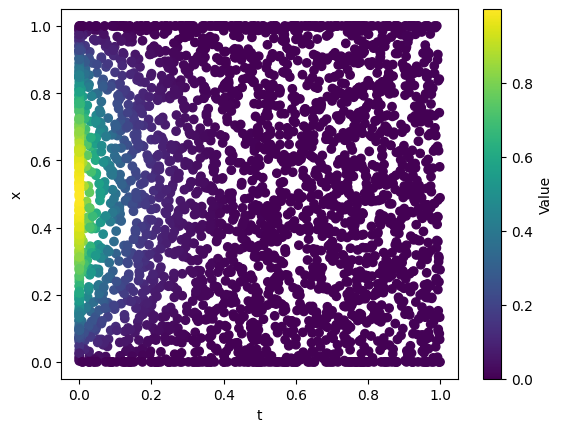

In [11]:
x_plot = torch.cat((X_colocacao, X_inicial, X_contorno))
y_pred = PINN_model(x_plot).detach().numpy()

plt.scatter(x_plot[:, 0], x_plot[:, 1:], c=y_pred, cmap="viridis", vmin=us.min(), vmax=us.max())
plt.xlabel('t')
plt.ylabel('x')
plt.colorbar(label='Value')
plt.show()